In [3]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models
import warnings
warnings.filterwarnings('ignore')
# warnings.simplefilter('ignore', FutureWarning)

In [ ]:
class ImageNoiseProvider:
    def __init__(self, root_dir, img_size=224):
        self.root_dir = root_dir
        self.img_size = img_size

    def load_data(self):
        images = []
        valid_extensions = ('.jpg', '.jpeg', '.png', '.webp')
        
        print(f"Scanning root directory: {self.root_dir}")
        # os.walk handles the nested DBZ/character_name structure
        for root, dirs, files in os.walk(self.root_dir):
            for filename in files:
                if filename.lower().endswith(valid_extensions):
                    path = os.path.join(root, filename)
                    img = cv2.imread(path)
                    if img is not None:
                        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
                        img = cv2.resize(img, (self.img_size, self.img_size))
                        images.append(img.astype('float32') / 255.0)
        
        return np.array(images)

    def inject_noise(self, data, noise_factor=0.15):
        # Anime lines are sharp; too much noise makes them unrecoverable
        # Too much noise - loss of edge information, Too little noise - no real learning
        noisy_data = data + noise_factor * np.random.normal(loc=0.0, scale=1.0, size=data.shape)
        return np.clip(noisy_data, 0., 1.)

In [ ]:
# Path to the main DBZ folder - BASE_PATH = '/path/to/local/image/folder'
BASE_PATH = '/kaggle/input/datasets/insaiyancvk/dragon-ball-z-dataset/DBZ' 

# 1. Prepare Data
provider = ImageNoiseProvider(root_dir=BASE_PATH)
x_clean = provider.load_data()
x_noisy = provider.inject_noise(x_clean, noise_factor=0.2)

Scanning root directory: /kaggle/input/datasets/insaiyancvk/dragon-ball-z-dataset/DBZ


In [6]:
class PrintCall(tf.keras.callbacks.Callback):
    def __init__(self, interval=10):
        self.interval = interval
        
    def on_epoch_end(self, epoch, logs=None):
        if (epoch + 1) % self.interval == 0:
            print(f"\nEpoch {epoch + 1}", end=" ")
            for k, v in logs.items():
                print(f"{k}: {v:.4f}", end=" ")

In [ ]:
class DenoisingAutoencoder:
    def __init__(self, input_shape=(224, 224, 3)):
        self.input_shape = input_shape
        self.model = self._build_model()

    def _build_model(self):
        input_layer = layers.Input(shape=self.input_shape)

        # Encoder: Downsampling
        x = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(input_layer)
        x = layers.MaxPooling2D((2, 2), padding='same')(x) # 112x112
        x = layers.Conv2D(128, (3, 3), activation='relu', padding='same')(x)
        x = layers.MaxPooling2D((2, 2), padding='same')(x) # 56x56
        x = layers.Conv2D(256, (3, 3), activation='relu', padding='same')(x)
        encoded = layers.MaxPooling2D((2, 2), padding='same')(x) # 28x28 (Bottleneck)

        # Decoder: Upsampling
        x = layers.Conv2DTranspose(256, (3, 3), strides=2, activation='relu', padding='same')(encoded)
        x = layers.Conv2DTranspose(128, (3, 3), strides=2, activation='relu', padding='same')(x)
        x = layers.Conv2DTranspose(64, (3, 3), strides=2, activation='relu', padding='same')(x)
        
        # Final reconstruction
        decoded = layers.Conv2D(3, (3, 3), activation='sigmoid', padding='same')(x)

        model = models.Model(input_layer, decoded)
        model.compile(optimizer='adam', loss='mse')
        return model

    def train(self, clean_data, noisy_data, epochs=50, batch_size=8):
        return self.model.fit(
            noisy_data, clean_data,
            epochs=epochs,
            batch_size=batch_size,
            shuffle=True,
            validation_split=0.1, # Keep some data to check progress
            callbacks=[PrintCall(interval=5)],
            verbose=0,
        )

    def compare_results(self, original, noisy, count=3):
        denoised = self.model.predict(noisy[:count])
        plt.figure(figsize=(12, 6))
        for i in range(count):
            # Noisy
            ax = plt.subplot(2, count, i + 1)
            plt.imshow(noisy[i])
            plt.title("Noisy Input")
            plt.axis("off")
            # Denoised
            ax = plt.subplot(2, count, i + 1 + count)
            plt.imshow(denoised[i])
            plt.title("Denoised Output")
            plt.axis("off")
        plt.show()

I0000 00:00:1772989207.628444      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1772989207.634219      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5
I0000 00:00:1772989224.622351     128 service.cc:152] XLA service 0x7c1ed8107910 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1772989224.622385     128 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1772989224.622389     128 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1772989225.108862     128 cuda_dnn.cc:529] Loaded cuDNN version 91002
2026-03-08 17:00:38.394691: E external/local_xla/xla/stream_executor/cuda/c


Epoch 5 loss: 0.0135 val_loss: 0.0116 
Epoch 10 loss: 0.0112 val_loss: 0.0097 
Epoch 15 loss: 0.0100 val_loss: 0.0087 
Epoch 20 loss: 0.0093 val_loss: 0.0083 
Epoch 25 loss: 0.0087 val_loss: 0.0079 

2026-03-08 17:24:42.846777: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-08 17:24:43.075033: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-08 17:24:43.395285: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-08 17:24:43.623279: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step


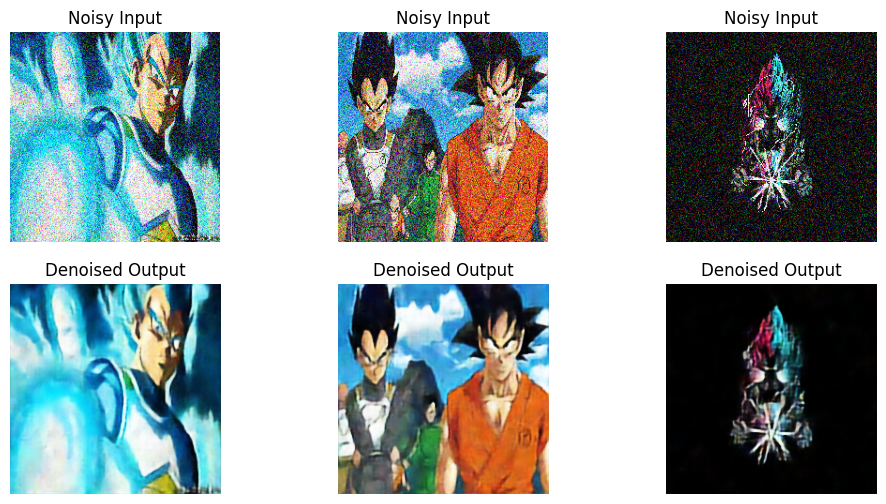

In [8]:
# 2. Build and Train
if len(x_clean) > 0:
    trainer = DenoisingAutoencoder()
    trainer.train(x_clean, x_noisy, epochs=25, batch_size=48) # Smaller batch for 224x224
    
    # 3. Visual Check
    trainer.compare_results(x_clean, x_noisy)
else:
    print("No images found! Check your BASE_PATH.")

In [9]:
trainer.model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose                │ (None, 56, 56, 256)    │       590,080 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_1              │ (None, 112, 112, 128)  │       295,040 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_2              │ (None, 224, 224, 64)   │        73,792 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 224, 224, 3)    │         1,731 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,994,379 (15.24 MB)

 Trainable params: 1,331,459 (5.08 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2,662,920 (10.16 MB)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step


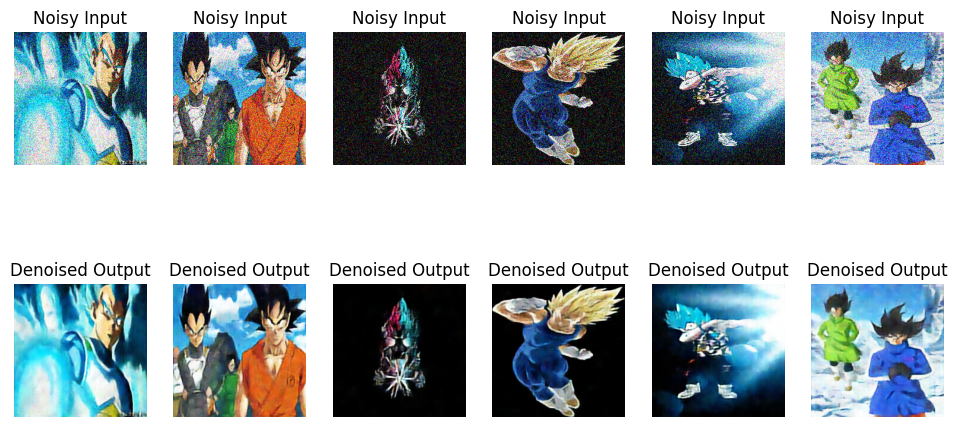

In [10]:
trainer.compare_results(x_clean, x_noisy, count=6)

In [11]:
# import shutil
# import os

# directory_path = file_path

# # Check if the directory exists before attempting deletion
# if os.path.exists(directory_path) and os.path.isdir(directory_path):
#     try:
#         shutil.rmtree(directory_path)
#         print(f"Directory '{directory_path}' and all its contents deleted successfully.")
#     except Exception as e:
#         print(f"Error deleting directory '{directory_path}': {e}")
# else:
#     print(f"Directory '{directory_path}' does not exist or is not a directory.")



In [ ]:
# 4. Save the model for later loading and inference 

file_path = "/kaggle/working/my_model.keras"

trainer.model.save(file_path)
print(f"Successfully exported model to {file_path}")

Successfully exported model to /kaggle/working/my_model.keras


In [ ]:
class DBZInference:
    def __init__(self, model_path):
        # Load with compile=False for inference only purpose, skips loss-related errors
        self.model = models.load_model(model_path, compile=False)

    def run_inference(self, image_path, noise_factor=0.1):
        # Load and resize to 224x224
        raw_img = cv2.imread(image_path)
        raw_img = cv2.cvtColor(raw_img, cv2.COLOR_BGR2RGB)
        resized = cv2.resize(raw_img, (224, 224)) / 255.0
        
        # Add noise for testing the denoiser
        noisy = resized + noise_factor * np.random.normal(0, 1, resized.shape)
        noisy = np.clip(noisy, 0, 1)
        
        # Predict
        input_batch = np.expand_dims(noisy, axis=0)
        denoised = self.model.predict(input_batch)[0]
        
        # Plot
        self._display(resized, noisy, denoised)

    def _display(self, original, noisy, denoised):
        fig, axes = plt.subplots(1, 3, figsize=(15, 5))
        axes[0].imshow(original); axes[0].set_title("Original")
        axes[1].imshow(noisy); axes[1].set_title("Noisy Input")
        axes[2].imshow(denoised); axes[2].set_title("Autoencoder Output")
        for ax in axes: ax.axis('off')
        plt.show()


In [ ]:
# To be tested yet...

# def evaluate_model(model, x_test_clean, x_test_noisy):
#     """Calculate MSE and PSNR on the test set."""
#     predictions = model.predict(x_test_noisy)
    
#     # Mean Squared Error
#     mse = np.mean((x_test_clean - predictions)**2)
    
#     # Calculate PSNR (Higher is better)
#     # Formula: 20 * log10(MAX_I) - 10 * log10(MSE)
#     psnr = tf.image.psnr(x_test_clean, predictions, max_val=1.0)
    
#     print(f"Test MSE: {mse:.4f}")
#     print(f"Average PSNR: {np.mean(psnr):.2f} dB")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 438ms/step


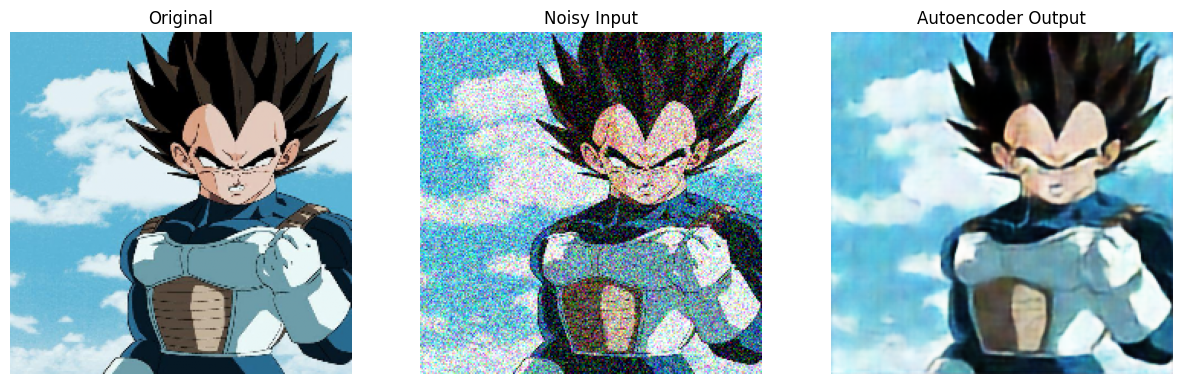

In [ ]:
# 5. Testing on a specific DBZ image (e.g. a new Vegeta pic)
inference_engine = DBZInference(model_path=r'/kaggle/working/my_model.keras')  # model_path = '/path/to/local/model/folder/model.keras'

# Test with a path to a new image
try:
    # image_path = '/path/to/local/image/folder/image.jpg'
    inference_engine.run_inference(image_path='/kaggle/input/datasets/insaiyancvk/dragon-ball-z-dataset/DBZ/vegeta/vegeta-047592c82eb411ec98ac04d4c47e1dbd.jpg', noise_factor=0.2)
except Exception as e:
    print(f"Error: {e}")

# 6. Batch Testing (to try further) 
# If you have x_test_clean and x_test_noisy arrays from your DataProvider
# evaluate_model(inference_engine.model, x_test_clean, x_test_noisy)

In [ ]:
# Alternate way of saving keras model and loading

file_path = "/kaggle/working/my_model"  # file_path = '/path/to/local/folder'

trainer.model.export(file_path)
print(f"Successfully exported model to {file_path}")

n_path = '/kaggle/working/my_model'
os.path.exists(n_path)
xyz = tf.saved_model.load(n_path)

INFO:tensorflow:Assets written to: /kaggle/working/my_model/assets


INFO:tensorflow:Assets written to: /kaggle/working/my_model/assets


Saved artifact at '/kaggle/working/my_model'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name=None)
Captures:
  136478482316560: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136478482317136: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136478482315024: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136478482315600: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136478482314448: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136478477682064: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136478477681872: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136478477681296: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136478477681680: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136478477681104: TensorSpec(shape=(), dtype=tf.resource, name=None

##### Dataset Used = 'https://www.kaggle.com/datasets/insaiyancvk/dragon-ball-z-dataset'
###### Dataset Creator - C Vamshi Krishna